In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings("ignore")
import joblib

In [19]:
df = pd.read_csv("sales_data.csv")

In [20]:
df.head()

,Order ID,Order Date,Ship Mode,Customer Name,Segment,Country,City,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,CA-2016-152156,11/8/2016,Second Class,Claire Gute,Consumer,United States,Henderson,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,CA-2016-152156,11/8/2016,Second Class,Claire Gute,Consumer,United States,Henderson,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,US-2015-108966,10/11/2015,Standard Class,Sean O'Donnell,Consumer,United States,Fort Lauderdale,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
3,CA-2014-115812,6/9/2014,Standard Class,Brosina Hoffman,Consumer,United States,Los Angeles,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
4,CA-2014-115812,6/9/2014,Standard Class,Brosina Hoffman,Consumer,United States,Los Angeles,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092


In [21]:
df.shape

(2121, 16)

In [22]:
df.head(3)

,Order ID,Order Date,Ship Mode,Customer Name,Segment,Country,City,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,CA-2016-152156,11/8/2016,Second Class,Claire Gute,Consumer,United States,Henderson,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,CA-2016-152156,11/8/2016,Second Class,Claire Gute,Consumer,United States,Henderson,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,US-2015-108966,10/11/2015,Standard Class,Sean O'Donnell,Consumer,United States,Fort Lauderdale,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2121 entries, 0 to 2120
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       2121 non-null   str    
 1   Order Date     2121 non-null   str    
 2   Ship Mode      2121 non-null   str    
 3   Customer Name  2121 non-null   str    
 4   Segment        2121 non-null   str    
 5   Country        2121 non-null   str    
 6   City           2121 non-null   str    
 7   Region         2121 non-null   str    
 8   Product ID     2121 non-null   str    
 9   Category       2121 non-null   str    
 10  Sub-Category   2121 non-null   str    
 11  Product Name   2121 non-null   str    
 12  Sales          2121 non-null   float64
 13  Quantity       2121 non-null   int64  
 14  Discount       2121 non-null   float64
 15  Profit         2121 non-null   float64
dtypes: float64(3), int64(1), str(12)
memory usage: 597.7 KB


In [24]:
df.describe()

,Sales,Quantity,Discount,Profit
count,2121.000000,2121.000000,2121.000000,2121.000000
mean,349.834887,3.785007,0.173923,8.699327
std,503.179145,2.251620,0.181547,136.049246
min,1.892000,1.000000,0.000000,-1862.312400
25%,47.040000,2.000000,0.000000,-12.849000
50%,182.220000,3.000000,0.200000,7.774800
75%,435.168000,5.000000,0.300000,33.726600
max,4416.174000,14.000000,0.700000,1013.127000


In [25]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2121 entries, 0 to 2120
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       2121 non-null   str           
 1   Order Date     2121 non-null   datetime64[us]
 2   Ship Mode      2121 non-null   str           
 3   Customer Name  2121 non-null   str           
 4   Segment        2121 non-null   str           
 5   Country        2121 non-null   str           
 6   City           2121 non-null   str           
 7   Region         2121 non-null   str           
 8   Product ID     2121 non-null   str           
 9   Category       2121 non-null   str           
 10  Sub-Category   2121 non-null   str           
 11  Product Name   2121 non-null   str           
 12  Sales          2121 non-null   float64       
 13  Quantity       2121 non-null   int64         
 14  Discount       2121 non-null   float64       
 15  Profit         2121 non-null   f

In [30]:
monthly_sales=df.groupby(pd.Grouper(key = "Order Date", freq="ME"))["Sales"].sum().reset_index()

monthly_sales.head()

,Order Date,Sales
0,2014-01-31,6242.525
1,2014-02-28,1839.658
2,2014-03-31,14573.956
3,2014-04-30,7944.837
4,2014-05-31,6912.787


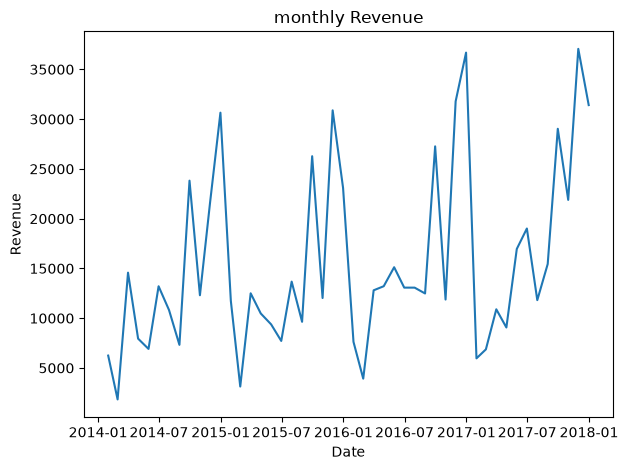

In [ ]:
plt.plot(monthly_sales["Order Date"], monthly_sales["Sales"])
plt.title("Monthly Sales Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

In [38]:
monthly_sales["year"] = monthly_sales["Order Date"].dt.year

In [39]:
monthly_sales.head()

,Order Date,Sales,year
0,2014-01-31,6242.525,2014
1,2014-02-28,1839.658,2014
2,2014-03-31,14573.956,2014
3,2014-04-30,7944.837,2014
4,2014-05-31,6912.787,2014


In [42]:
monthly_sales["month"] = monthly_sales["Order Date"].dt.month
monthly_sales["quarter"] = monthly_sales["Order Date"].dt.quarter

In [44]:
monthly_sales.tail()

,Order Date,Sales,year,month,quarter
43,2017-08-31,15441.8740,2017,8,3
44,2017-09-30,29028.2060,2017,9,3
45,2017-10-31,21884.0682,2017,10,4
46,2017-11-30,37056.7150,2017,11,4
47,2017-12-31,31407.4668,2017,12,4


In [45]:
monthly_sales["lag_1"] = monthly_sales["Sales"].shift(1)

In [46]:
monthly_sales.head()

,Order Date,Sales,year,month,quarter,lag_1
0,2014-01-31,6242.525,2014,1,1,NaN
1,2014-02-28,1839.658,2014,2,1,6242.525
2,2014-03-31,14573.956,2014,3,1,1839.658
3,2014-04-30,7944.837,2014,4,2,14573.956
4,2014-05-31,6912.787,2014,5,2,7944.837


In [47]:
monthly_sales["lag_2"] = monthly_sales["Sales"].shift(2)
monthly_sales["lag_3"] = monthly_sales["Sales"].shift(3)
monthly_sales["lag_12"] = monthly_sales["Sales"].shift(12)

In [51]:
monthly_sales.head()

,Order Date,Sales,year,month,quarter,lag_1,lag_2,lag_3,lag_12
0,2014-01-31,6242.525,2014,1,1,NaN,NaN,NaN,NaN
1,2014-02-28,1839.658,2014,2,1,6242.525,NaN,NaN,NaN
2,2014-03-31,14573.956,2014,3,1,1839.658,6242.525,NaN,NaN
3,2014-04-30,7944.837,2014,4,2,14573.956,1839.658,6242.525,NaN
4,2014-05-31,6912.787,2014,5,2,7944.837,14573.956,1839.658,NaN


In [52]:
monthly_sales["rolling_mean_3"] = monthly_sales["Sales"].shift(1).rolling(3).mean()
monthly_sales["rolling_std_3"] = monthly_sales["Sales"].shift(1).rolling(3).std()

In [53]:
monthly_sales

,Order Date,Sales,year,month,quarter,lag_1,lag_2,lag_3,lag_12,rolling_mean_3,rolling_std_3
0,2014-01-31,6242.5250,2014,1,1,NaN,NaN,NaN,NaN,NaN,NaN
1,2014-02-28,1839.6580,2014,2,1,6242.5250,NaN,NaN,NaN,NaN,NaN
2,2014-03-31,14573.9560,2014,3,1,1839.6580,6242.5250,NaN,NaN,NaN,NaN
3,2014-04-30,7944.8370,2014,4,2,14573.9560,1839.6580,6242.5250,NaN,7552.046333,6467.358114
4,2014-05-31,6912.7870,2014,5,2,7944.8370,14573.9560,1839.6580,NaN,8119.483667,6368.945162
5,2014-06-30,13206.1256,2014,6,2,6912.7870,7944.8370,14573.9560,NaN,9810.526667,4157.400156
6,2014-07-31,10821.0510,2014,7,3,13206.1256,6912.7870,7944.8370,NaN,9354.583200,3375.213467
7,2014-08-31,7320.3465,2014,8,3,10821.0510,13206.1256,6912.7870,NaN,10313.321200,3177.242491
8,2014-09-30,23816.4808,2014,9,3,7320.3465,10821.0510,13206.1256,NaN,10449.174367,2960.459099
9,2014-10-31,12304.2470,2014,10,4,23816.4808,7320.3465,10821.0510,NaN,13985.959433,8691.553127


In [54]:
monthly_sales.columns

Index(['Order Date', 'Sales', 'year', 'month', 'quarter', 'lag_1', 'lag_2',
       'lag_3', 'lag_12', 'rolling_mean_3', 'rolling_std_3'],
      dtype='str')

In [55]:
monthly_sales.shape

(48, 11)

In [56]:
monthly_sales.dropna(inplace=True)

In [57]:
monthly_sales.shape

(36, 11)

In [60]:
X = monthly_sales.drop(["Order Date", "Sales"],axis = 1)
y = monthly_sales["Sales"]

In [61]:
X

,year,month,quarter,lag_1,lag_2,lag_3,lag_12,rolling_mean_3,rolling_std_3
12,2015,1,1,30645.9665,21564.8727,12304.2470,6242.5250,21505.028733,9171.006190
13,2015,2,1,11739.9416,30645.9665,21564.8727,1839.6580,21316.926933,9455.450926
14,2015,3,1,3134.3740,11739.9416,30645.9665,14573.9560,15173.427367,14073.505209
15,2015,4,2,12499.7830,3134.3740,11739.9416,7944.8370,9124.699533,5201.667015
16,2015,5,2,10475.6985,12499.7830,3134.3740,6912.7870,8703.285167,4927.860408
17,2015,6,2,9374.9505,10475.6985,12499.7830,13206.1256,10783.477333,1584.989084
18,2015,7,3,7714.1790,9374.9505,10475.6985,10821.0510,9188.276000,1390.191718
19,2015,8,3,13674.4200,7714.1790,9374.9505,7320.3465,10254.516500,3075.930015
20,2015,9,3,9638.5922,13674.4200,7714.1790,23816.4808,10342.397067,3041.812644
21,2015,10,4,26273.0230,9638.5922,13674.4200,12304.2470,16528.678400,8676.760068


In [71]:
split_date = "2017-01-01"
X_train = X[monthly_sales["Order Date"]< split_date]
X_test = X[monthly_sales["Order Date"] >= split_date]


y_train = y[monthly_sales["Order Date"] < split_date]
y_test = y[monthly_sales["Order Date"] >= split_date]

In [64]:
X_train

,year,month,quarter,lag_1,lag_2,lag_3,lag_12,rolling_mean_3,rolling_std_3
12,2015,1,1,30645.9665,21564.8727,12304.2470,6242.5250,21505.028733,9171.006190
13,2015,2,1,11739.9416,30645.9665,21564.8727,1839.6580,21316.926933,9455.450926
14,2015,3,1,3134.3740,11739.9416,30645.9665,14573.9560,15173.427367,14073.505209
15,2015,4,2,12499.7830,3134.3740,11739.9416,7944.8370,9124.699533,5201.667015
16,2015,5,2,10475.6985,12499.7830,3134.3740,6912.7870,8703.285167,4927.860408
17,2015,6,2,9374.9505,10475.6985,12499.7830,13206.1256,10783.477333,1584.989084
18,2015,7,3,7714.1790,9374.9505,10475.6985,10821.0510,9188.276000,1390.191718
19,2015,8,3,13674.4200,7714.1790,9374.9505,7320.3465,10254.516500,3075.930015
20,2015,9,3,9638.5922,13674.4200,7714.1790,23816.4808,10342.397067,3041.812644
21,2015,10,4,26273.0230,9638.5922,13674.4200,12304.2470,16528.678400,8676.760068


In [66]:
X_test

,year,month,quarter,lag_1,lag_2,lag_3,lag_12,rolling_mean_3,rolling_std_3
36,2017,1,1,36678.7150,31783.6288,11872.5770,7622.7430,26778.306933,13138.723525
37,2017,2,1,5964.0320,36678.7150,31783.6288,3925.5510,24808.791933,16502.551316
38,2017,3,1,6866.3374,5964.0320,36678.7150,12801.0920,16503.028133,17478.480888
39,2017,4,2,10893.4448,6866.3374,5964.0320,13212.0900,7907.938067,2624.590749
40,2017,5,2,9065.9581,10893.4448,6866.3374,15119.8350,8941.913433,2016.417321
41,2017,6,2,16957.5582,9065.9581,10893.4448,13070.5720,12305.653700,4130.991227
42,2017,7,3,19008.5867,16957.5582,9065.9581,13068.5190,15010.701000,5249.443360
43,2017,8,3,11813.0220,19008.5867,16957.5582,12483.2323,15926.388967,3706.955669
44,2017,9,3,15441.8740,11813.0220,19008.5867,27262.8809,15421.160900,3597.827068
45,2017,10,4,29028.2060,15441.8740,11813.0220,11872.5770,18761.034000,9074.869551


In [73]:
model = XGBRegressor(
    n_estimators = 500,
    learning_rate =0.05,
    max_depth = 5,
    subsample = 0.8,
    colsample_bytree = 0.8
)

In [74]:
model.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [75]:
train_preds = model.predict(X_train)
test_preds = model.predict(X_test)

In [78]:
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true,y_pred)
    rmse =np.sqrt(mean_squared_error(y_true,y_pred))
    r2 = r2_score(y_true,y_pred)

    print("Mae:", mae)
    print("RMSE:",rmse)
    print("R2:", r2)




In [79]:
print("Train Performance")
evaluate(y_train, train_preds)

print("Test Performance")
evaluate(y_test, test_preds)

Train Performance
Mae: 0.3795744303383988
RMSE: 0.6612781391498109
R2: 0.9999999943389704
Test Performance
Mae: 4373.817417252604
RMSE: 5201.717078432674
R2: 0.7115531752603154


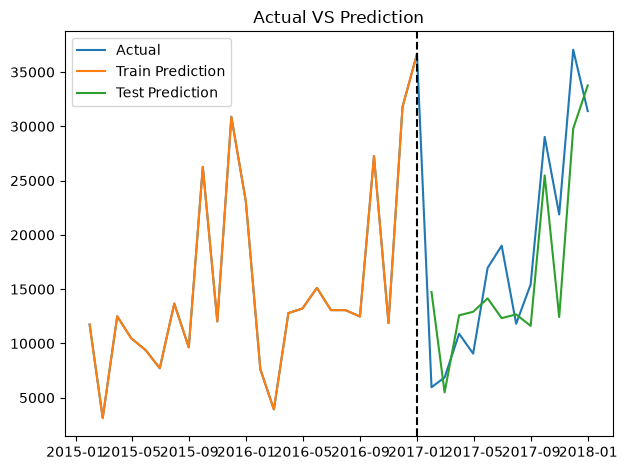

In [86]:
plt.plot(monthly_sales["Order Date"],monthly_sales["Sales"], label = "Actual")
plt.plot(monthly_sales["Order Date"][monthly_sales["Order Date"] < split_date], train_preds,label="Train Prediction")
plt.plot(monthly_sales["Order Date"][monthly_sales["Order Date"] >=split_date],test_preds, label = "Test Prediction")

plt.axvline(pd.to_datetime(split_date),color = "black",linestyle="--")
plt.legend()

plt.title("Actual VS Prediction")
plt.tight_layout()
plt.show()

In [95]:
future_Prediction = []

last_data = monthly_sales.copy()

for i in range(12):
    last_row = last_data.iloc[[-1]]
    next_month = last_row["Order Date"] + pd.DateOffset(months = 1)

    new_row = pd.DataFrame({
        "Order Date": next_month,
        "year":next_month.dt.year,
        "month":next_month.dt.month,
        "quarter":next_month.dt.quarter,
        "lag_1":last_row["Sales"].values,
        "lag_2": last_row["lag_1"].values,
        "lag_3": last_row["lag_2"].values,
        "lag_12": last_row["lag_12"].values,
        "rolling_mean_3":last_row["rolling_mean_3"].values,
        "rolling_std_3": last_row["rolling_std_3"].values
    })

    X_new = new_row.drop(["Order Date"], axis = 1)
    pred = model.predict(X_new)[0]
    new_row["Sales"] = pred
    future_Prediction.append(new_row)

    last_data = pd.concat([last_data,new_row],ignore_index = True)

In [96]:
future_df = pd.concat(future_Prediction)

In [97]:
future_df

,Order Date,year,month,quarter,lag_1,lag_2,lag_3,lag_12,rolling_mean_3,rolling_std_3,Sales
47,2018-01-31,2018,1,1,31407.466800,37056.715000,21884.068200,36678.715,29322.9964,7590.617812,24873.507812
36,2018-02-28,2018,2,1,24873.507812,31407.466800,37056.715000,36678.715,29322.9964,7590.617812,24438.894531
37,2018-03-28,2018,3,1,24438.894531,24873.507812,31407.466800,36678.715,29322.9964,7590.617812,24845.076172
38,2018-04-28,2018,4,2,24845.076172,24438.894531,24873.507812,36678.715,29322.9964,7590.617812,24801.255859
39,2018-05-28,2018,5,2,24801.255859,24845.076172,24438.894531,36678.715,29322.9964,7590.617812,24803.123047
40,2018-06-28,2018,6,2,24803.123047,24801.255859,24845.076172,36678.715,29322.9964,7590.617812,24803.123047
41,2018-07-28,2018,7,3,24803.123047,24803.123047,24801.255859,36678.715,29322.9964,7590.617812,24807.281250
42,2018-08-28,2018,8,3,24807.281250,24803.123047,24803.123047,36678.715,29322.9964,7590.617812,24798.566406
43,2018-09-28,2018,9,3,24798.566406,24807.281250,24803.123047,36678.715,29322.9964,7590.617812,26124.242188
44,2018-10-28,2018,10,4,26124.242188,24798.566406,24807.281250,36678.715,29322.9964,7590.617812,27038.644531


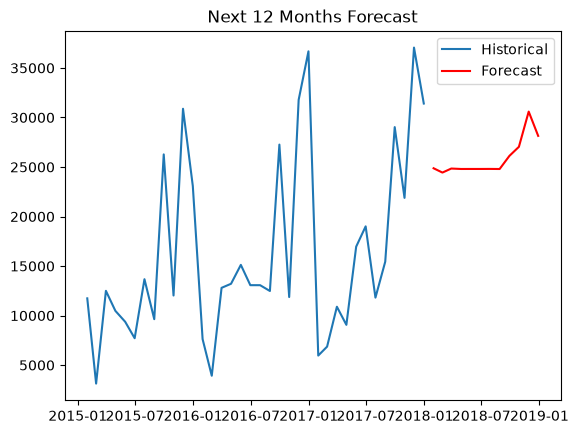

In [100]:
plt.plot(monthly_sales["Order Date"],monthly_sales["Sales"], label = "Historical")

plt.plot(future_df["Order Date"],future_df["Sales"],label = "Forecast", color="red")

plt.legend()
plt.title("Next 12 Months Forecast")
plt.show()

In [101]:
model

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [104]:
joblib.dump(model, "sales_forecasting_model.pkl")

['sales_forecasting_model.pkl']